In [1]:
! pip install langchain_community tiktoken langchain-openai langchainhub chromadb langchain

In [1]:
import os
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = "*******"

In [2]:
os.environ['OPENAI_API_KEY'] = "******"

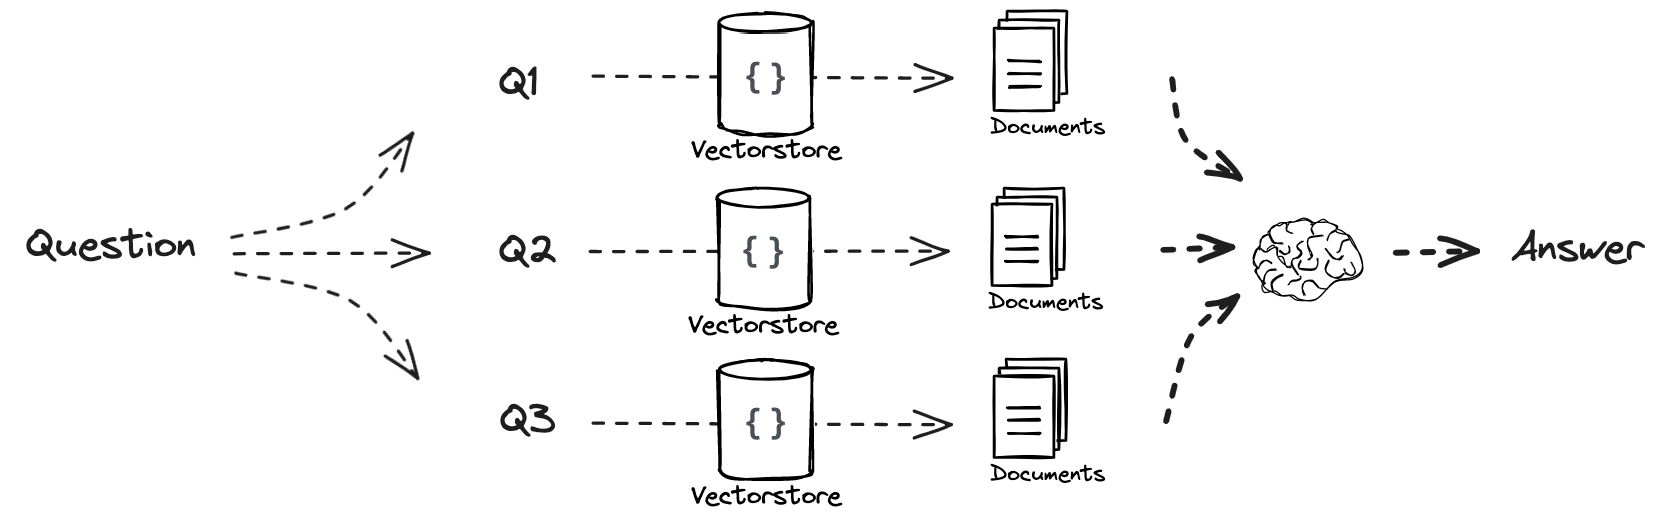

In [ ]:
##INDEXING##

# Load blog
import bs4
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter # Updated import
from langchain_community.vectorstores import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
import os

#LOAD DOC
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
#pdf_docs = PyPDFLoader("my_pdf").loager()

blog_docs = loader.load()

# Split
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50)

# Make splits
splits = text_splitter.split_documents(blog_docs)

# Index
vectorstore = Chroma.from_documents(documents=splits,
                                    embedding=OpenAIEmbeddings())

retriever = vectorstore.as_retriever()

#Load the doc, split the dcument,embedd in a vector database

In [ ]:
#Prompts - different perspectives to the query
from langchain.prompts import ChatPromptTemplate
from langchain.chat_models import ChatOpenAI
from langchain.schema.output_parser import StrOutputParser

template = """You are an AI language model assistant. Your task is to generate five
different versions of the given user question to retrieve relevant documents from a vector
database. By generating multiple perspectives on the user question, your goal is to help
the user overcome some of the limitations of the distance-based similarity search.
Provide these alternative questions separated by newlines. Original question: {question}"""

perspectives = ChatPromptTemplate.from_template(template)
llm = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0)


queries = (
    perspectives
    | llm
    | StrOutputParser()
    | (lambda x: x.split("\n")
)

#Created different prompt perspectives to our query and generated the answers.
#To remove duplicate retrivals of the same document we use a get union function.



In [ ]:
from langchain.load import dumps, loads  # fixed import

def get_unique_union(documents: list[list]):
    """ Unique union of retrieved docs """
    # Flatten the list of lists
    flattened_docs = [dumps(doc) for sublist in documents for doc in sublist]
    # Deduplicate
    unique_docs = list(set(flattened_docs))
    # Deserialize and return
    return [loads(doc) for doc in unique_docs]

# Build chain from generate_queries (defined earlier)
retrieval_chain = queries | retriever.map() | get_unique_union

# Retrieve
question = "What is the capital of France?"
retrieved_docs = retrieval_chain.invoke({"question": question})
print(len(retrieved_docs))



# **GENERATION**

In [ ]:
from operator import itemgetter
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnablePassthrough

template =  """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

llm = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0)

final_chain = (
    {
        "context": itemgetter("question") | retriever | (lambda docs: "\n\n".join(d.page_content for d in docs)),
        "question": itemgetter("question")  # fixed — question must pass through too
    }
    |prompt
    | llm
    | StrOutputParser()
)
final_chain.invoke({"question": question})


# **RAG_FUSION**

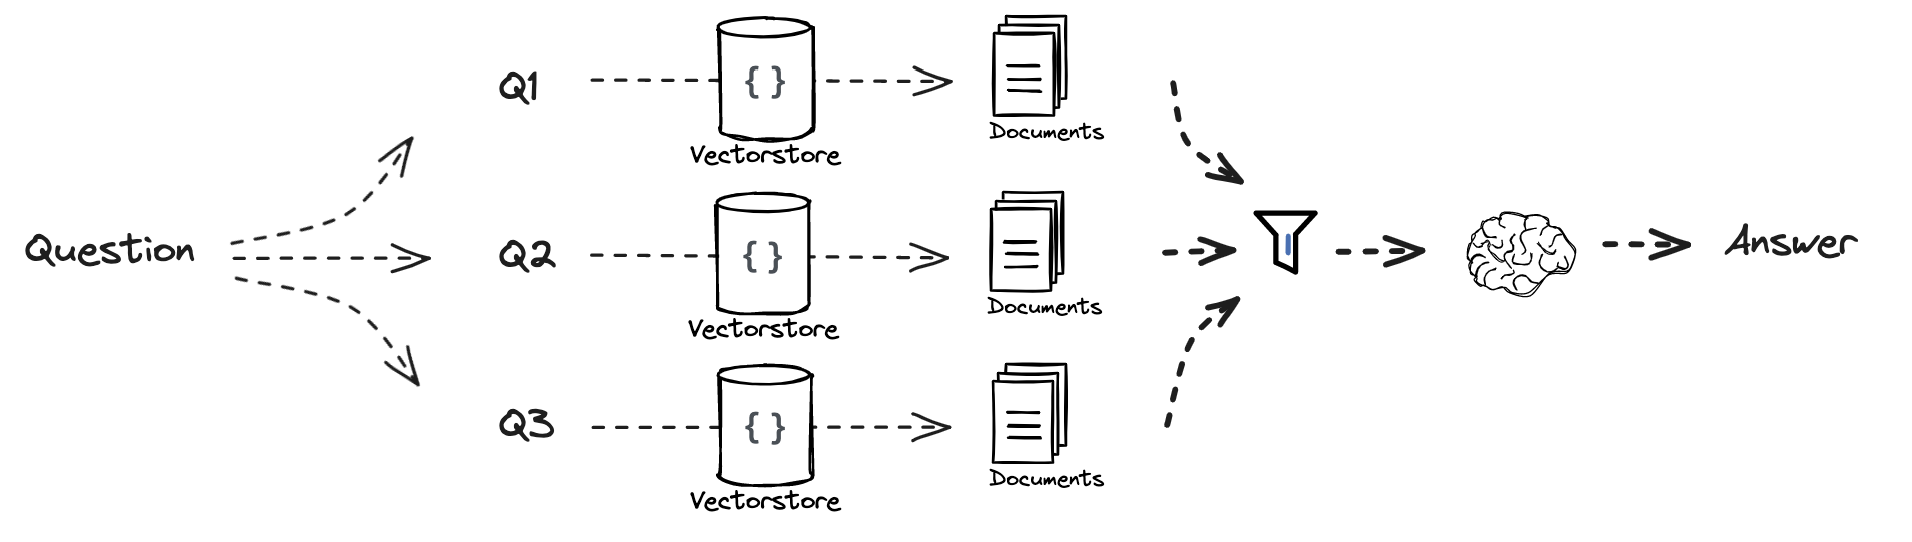

In [ ]:
#Reduces many noisy results
#Some are irrelevant and week
#Aims to boost documents that appear in multiple searches of the different queries created.

#PROMPTS
from langchain.prompts import ChatPromptTemplate
template = """You are a helpful assistant that generates multiple search queries based on a single input query. \n
Generate multiple search queries related to: {question} \n
Output (4 queries):"""

prompt_rag_fusion = ChatPromptTemplate.from_template(template)

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

generate_queries = (
    prompt_rag_fusion
    | ChatOpenAI(model_name="gpt-3.5-turbo")
    | StrOutputParser()
    | (lambda x: x.split("\n")
)

In [ ]:
from langchain.load import dumps, loads

def reciprocal_rank_fusion(results: list[list], k=60):
    """ Reciprocal_rank_fusion that takes multiple lists of ranked documents
        and an optional parameter k used in the RRF formula """

    # Initialize a dictionary to hold fused scores for each unique document
    fused_scores = {}

    # Iterate through each list of ranked documents
    for docs in results:
        # Iterate through each document in the list, with its rank (position in the list)
        for rank, doc in enumerate(docs):
            # Convert the document to a string format to use as a key (assumes documents can be serialized to JSON)
            doc_str = dumps(doc)
            # If the document is not yet in the fused_scores dictionary, add it with an initial score of 0
            if doc_str not in fused_scores:
                fused_scores[doc_str] = 0
            # Retrieve the current score of the document, if any
            previous_score = fused_scores[doc_str]
            # Update the score of the document using the RRF formula: 1 / (rank + k)
            fused_scores[doc_str] += 1 / (rank + k)

    # Sort the documents based on their fused scores in descending order to get the final reranked results
    reranked_results = [
        (loads(doc), score)
        for doc, score in sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)
    ]

    # Return the reranked results as a list of tuples, each containing the document and its fused score
    return reranked_results

retrieval_chain_rag_fusion = generate_queries | retriever.map() | reciprocal_rank_fusion
docs = retrieval_chain_rag_fusion.invoke({"question": question})
len(docs)

In [ ]:
from langchain_core.runables import RunnablePassThrough
template =  """Answer the following question based on this context:

{context}

Question: {question}
"""
prompt_rank = ChatPromptTemplate.from_template(template)

fusion_rag = (
    {"context": RunnablePassThrough(), "question": itemgetter("question")}
    | prompt_rank
    | ChatOpenAI(model_name="gpt-3.5-turbo")
    | StrOutputParser()
)
final_chain = fusion_rag.invoke({"question": question, "context": docs})
print(final_chain)

# **DECOMPOSITION**

In [ ]:
from langchain.prompts import ChatPromptTemplate

# Decomposition
template = """You are a helpful assistant that generates multiple sub-questions related to an input question. \n
The goal is to break down the input into a set of sub-problems / sub-questions that can be answers in isolation. \n
Generate multiple search queries related to: {question} \n
Output (3 queries):"""
prompt_decomposition = ChatPromptTemplate.from_template(template)

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model_name="gpt-3.5")

generate_queries =(
    prompt_decomposition
    | llm
    | StrOutputParser()
)
question = "What are the main components of an LLM-powered autonomous agent system?"
questions = generate_queries_decomposition.invoke({"question":question})

In [ ]:
questions

In [ ]:

from langchain import hub
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

# RAG prompt
prompt_rag = hub.pull("rlm/rag-prompt")

def retrieve_and_rag(question,prompt_rag,sub_question_generator_chain):
    """RAG on each sub-question"""

    # Use our decomposition /
    sub_questions = sub_question_generator_chain.invoke({"question":question})

    # Initialize a list to hold RAG chain results
    rag_results = []

    for sub_question in sub_questions:

        # Retrieve documents for each sub-question
        retrieved_docs = retriever.get_relevant_documents(sub_question)

        # Use retrieved documents and sub-question in RAG chain
        answer = (prompt_rag | llm | StrOutputParser()).invoke({"context": retrieved_docs,
                                                                "question": sub_question})
        rag_results.append(answer)

    return rag_results,sub_questions

# Wrap the retrieval and RAG process in a RunnableLambda for integration into a chain
answers, questions = retrieve_and_rag(question, prompt_rag, generate_queries_decomposition)

In [ ]:
def format_qa_pairs(questions, answers):
    """Format Q and A pairs"""

    formatted_string = ""
    for i, (question, answer) in enumerate(zip(questions, answers), start=1):
        formatted_string += f"Question {i}: {question}\nAnswer {i}: {answer}\n\n"
    return formatted_string.strip()

context = format_qa_pairs(questions, answers)

# Prompt
template = """Here is a set of Q+A pairs:

{context}

Use these to synthesize an answer to the question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    prompt
    | llm
    | StrOutputParser()
)

final_rag_chain.invoke({"context":context,"question":question})


# **HYDE**

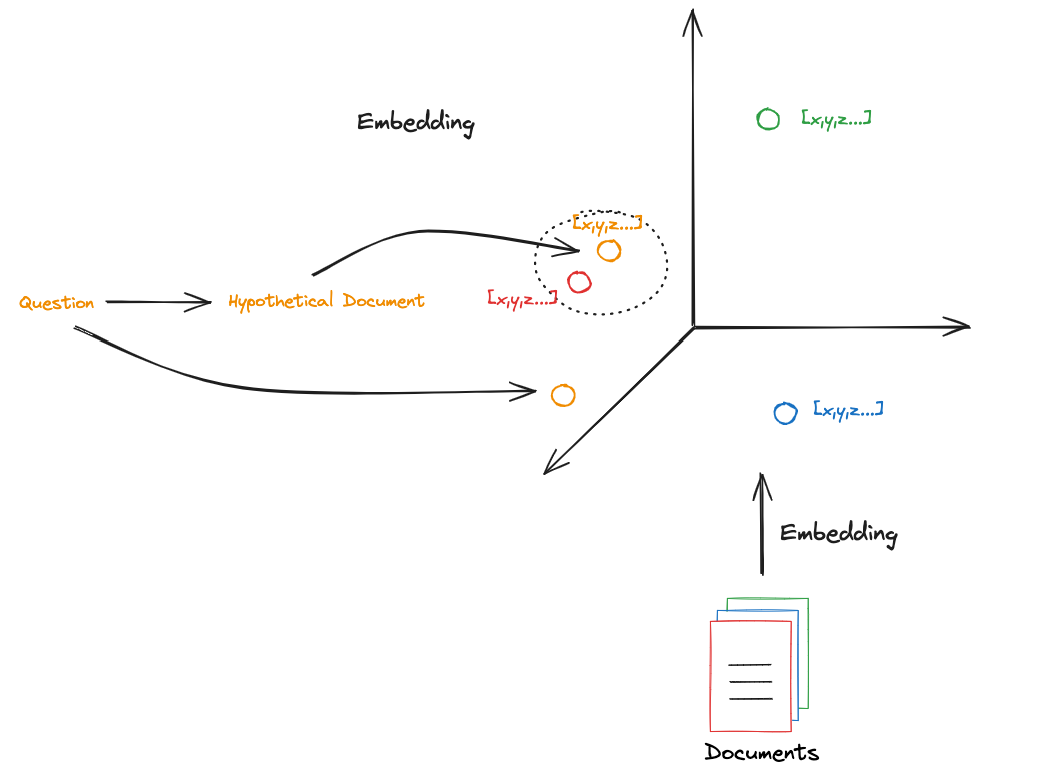

In [ ]:
#Generates a fake answer to a query,embeds it and finds its similirarity in the vector db. From this it generates the real answer
#This is helpful since writing styles of diffeent docs is different
from langchain.prompts import ChatPromptTemplate

# HyDE document generation
template = """Please write a scientific paper passage to answer the question
Question: {question}
Passage:"""
prompt_hyde = ChatPromptTemplate.from_template(template)

from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

generate_docs_for_retrieval = (
    prompt_hyde | ChatOpenAI(temperature=0) | StrOutputParser()
)

# Run
question = "What is task decomposition for LLM agents?"
generate_docs_for_retrieval.invoke({"question":question})


In [ ]:
# Retrieve
retrieval_chain = generate_docs_for_retrieval | retriever
retrieved_docs = retrieval_chain.invoke({"question":question})
retrieved_docs

In [ ]:
# RAG
template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    prompt
    | llm
    | StrOutputParser()
)

final_rag_chain.invoke({"context":retrieved_docs,"question":question})